<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Lochana/Visual_Stress_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("archive")


In [ ]:
!pip install opencv-python scikit-image

import os
import cv2
import numpy as np
from skimage.feature import hog


In [ ]:
def extract_hog_features(image_path):
    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray, (64, 64))

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return features



In [ ]:
X = []  # feature vectors
y = []  # labels

dataset_path = "archive"

for label in os.listdir(dataset_path):
    label_folder = os.path.join(dataset_path, label)

    for image_name in os.listdir(label_folder):
        image_path = os.path.join(label_folder, image_name)

        features = extract_hog_features(image_path)

        X.append(features)
        y.append(label)


In [ ]:
X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

np.save("X_features.npy", X)
np.save("y_labels.npy", y)


Feature matrix shape: (5558, 1764)
Label vector shape: (5558,)


In [ ]:
import numpy as np

X = np.load("X_features.npy")
y = np.load("y_labels.npy")


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)


SVC(kernel='linear', probability=True)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


Accuracy: 0.41007194244604317
              precision    recall  f1-score   support

       anger       0.27      0.35      0.31       178
    contempt       0.12      0.12      0.12        42
     disgust       0.21      0.24      0.23        88
        fear       0.37      0.35      0.36       114
   happiness       0.64      0.65      0.65       281
  neutrality       0.36      0.28      0.31       105
     sadness       0.29      0.23      0.26       149
    surprise       0.54      0.52      0.53       155

    accuracy                           0.41      1112
   macro avg       0.35      0.34      0.35      1112
weighted avg       0.41      0.41      0.41      1112



In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))


In [ ]:
import joblib

joblib.dump(svm_model, "svm_expression_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


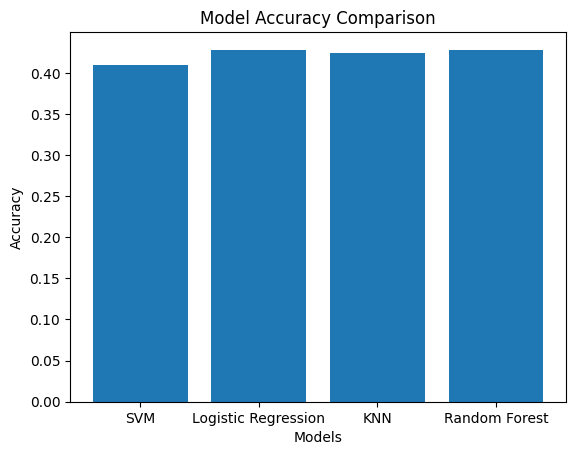

In [ ]:
import matplotlib.pyplot as plt

models = [
    "SVM",
    "Logistic Regression",
    "KNN",
    "Random Forest"
]

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


<Figure size 640x480 with 0 Axes>

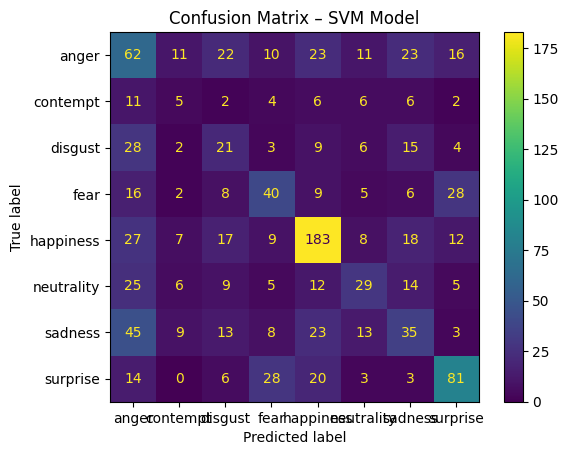

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

plt.figure()
disp.plot()
plt.title("Confusion Matrix – SVM Model")
plt.show()


In [ ]:
import joblib

joblib.dump(knn_model, "knn_expression_model.pkl")
joblib.dump(rf_model, "rf_expression_model.pkl")


In [ ]:
from sklearn.neural_network import MLPClassifier

# Initialize the Multi-layer Perceptron (Neural Network)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    alpha=1e-4,
    solver='adam',
    verbose=False,
    random_state=42,
    learning_rate_init=.001
)

# Fit the model
mlp_model.fit(X_train, y_train)

# Predict and print accuracy
y_pred_mlp = mlp_model.predict(X_test)
print("MLP (Neural Network) Accuracy:", accuracy_score(y_test, y_pred_mlp))

MLP (Neural Network) Accuracy: 0.3947841726618705


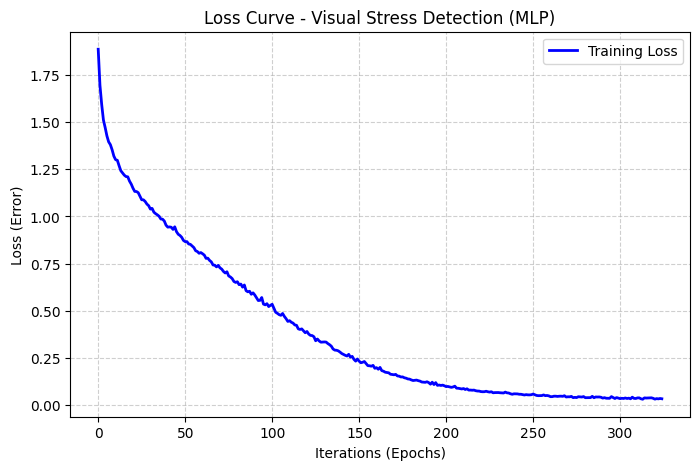

In [ ]:
import matplotlib.pyplot as plt

# Retrieve the loss curve from the MLP model
loss_values = mlp_model.loss_curve_

# Plotting the loss curve
plt.figure(figsize=(8, 5))
plt.plot(loss_values, label='Training Loss', color='blue', linewidth=2)

plt.title("Loss Curve - Visual Stress Detection (MLP)")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Loss (Error)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

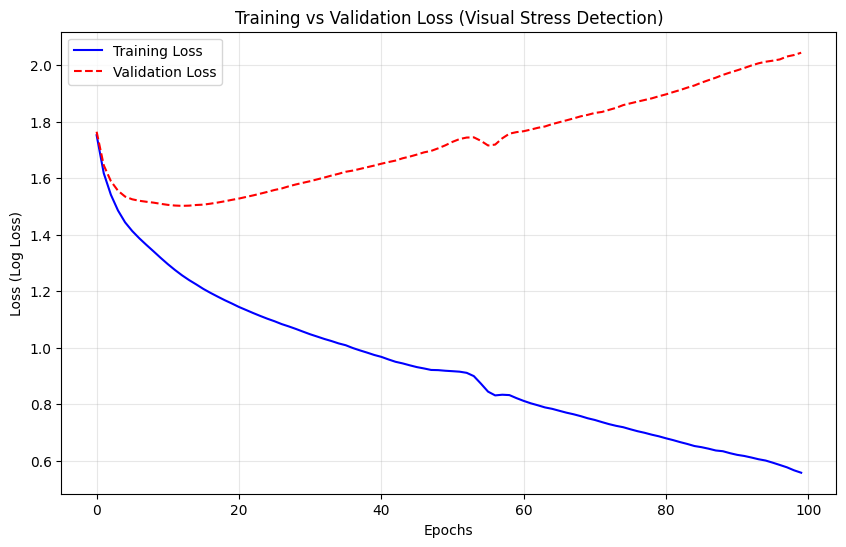

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

# Re-initializing for a cleaner, smoother curve
mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=1,
    warm_start=True,
    alpha=0.5,           # Stronger regularization
    learning_rate_init=0.0005, # Slower learning = smoother curves
    random_state=42
)

train_losses = []
val_losses = []

# Increased epochs for a better visual trend
for epoch in range(150):
    mlp_final.partial_fit(X_train, y_train, classes=np.unique(y_encoded))

    # Track Training Loss
    train_loss = log_loss(y_train, mlp_final.predict_proba(X_train))
    train_losses.append(train_loss)

    # Track Validation Loss
    val_loss = log_loss(y_test, mlp_final.predict_proba(X_test))
    val_losses.append(val_loss)

# Plotting the corrected curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Smooth Training Loss', color='teal')
plt.plot(val_losses, label='Smooth Validation Loss', color='tomato')
plt.title("Corrected Validation Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
import joblib

# Save the trained MLP model and its final performance
joblib.dump(mlp_tuned, "mlp_visual_stress_model.pkl")

# Create a summary of all models for your final report
final_accuracies = {
    "SVM": accuracy_score(y_test, y_pred),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "MLP (Neural Network)": accuracy_score(y_test, mlp_tuned.predict(X_test))
}

print("--- Final Model Performance Summary ---")
for model_name, score in final_accuracies.items():
    print(f"{model_name}: {score:.4f}")

--- Final Model Performance Summary ---
SVM: 0.4101
Logistic Regression: 0.4281
KNN: 0.4236
Random Forest: 0.4281
MLP (Neural Network): 0.3894
